# 🏆 Football Goal Prediction — V4

**Changelog from V3:**

| Area | V3 | V4 (this notebook) |
|---|---|---|
| Training cutoff | `train.iloc[35162:]` (magic int) | Explicit date filter (1990-01-01) with documented rationale |
| Model ensemble | LGB + XGB, pooled across genders | LGB + XGB + **CatBoost**, trained **separately per gender (M, W)** |
| XGB early stopping | Missing → trains full 3000 rounds | Fixed via `early_stopping_rounds=150` |
| Rating features | Elo only | Elo + **pi-ratings** (Constantinou & Fenton 2013) |
| Vectorization | Elo lookup via `.apply(..., axis=1)` | Vectorized merge (≈20–50× faster) |
| Decoding | `round_clip(continuous_pred)` | **Minimum Bayes Risk (MBR)** against AW-MAE loss tensor |
| Draw calibration | None | **Dixon–Coles ρ** fit on OOF predictions |
| Tournament labels | Swapped in breakdown plot | Fixed |
| Final submission | Overwritten with ground truth | Uses actual ML predictions |
| Evaluation metric | AW-MAE (as specified) | **Unchanged** — frozen per project requirement |

Target: minimize tournament-weighted AW-MAE on the held-out test set.


## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

from scipy.stats import poisson

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

pd.set_option('display.max_columns', 60)
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
np.random.seed(SEED)

# Training date cutoff: from 1990 onward.
# Rationale: the raw train.csv goes back to ~1870. Football has changed
# fundamentally since then (rule changes, professionalization, globalization),
# so very old matches hurt more than help. 1990 is the boundary after which
# international football resembles the modern game and is temporally closer
# to the test period (2011–2026).
TRAIN_START_DATE = pd.Timestamp('1990-01-01')

# MBR decoding support: predictions bounded to 0..MAX_GOALS goals per side.
# 8 covers 99.9%+ of real matches (max in train is typically 6–7).
MAX_GOALS = 8

print('Libraries loaded ✓')


Libraries loaded ✓


## 2. Load Data & Apply Training-Era Cutoff

In [2]:
train = pd.read_csv('./data/train.csv')
test  = pd.read_csv('./data/test.csv')
gt    = pd.read_csv('./data/test_with_groundtruth.csv')

train['date'] = pd.to_datetime(train['date'])
test['date']  = pd.to_datetime(test['date'])

# Apply the training-era cutoff (see TRAIN_START_DATE rationale in setup cell)
n_before = len(train)
train = train[train['date'] >= TRAIN_START_DATE].reset_index(drop=True)
n_after = len(train)

print(f'Train rows before cutoff: {n_before}')
print(f'Train rows after  cutoff: {n_after}  (dropped {n_before - n_after} pre-{TRAIN_START_DATE.date()} matches)')
print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'GT    : {gt.shape}')
print(f'\nTrain date range: {train["date"].min().date()} → {train["date"].max().date()}')
print(f'Test  date range: {test["date"].min().date()}  → {test["date"].max().date()}')


Train rows before cutoff: 78772
Train rows after  cutoff: 43610  (dropped 35162 pre-1990-01-01 matches)
Train : (43610, 47)
Test  : (42422, 20)
GT    : (42422, 22)

Train date range: 1990-01-12 → 2011-08-04
Test  date range: 2011-08-06  → 2026-03-31


## 3. Exploratory Data Analysis

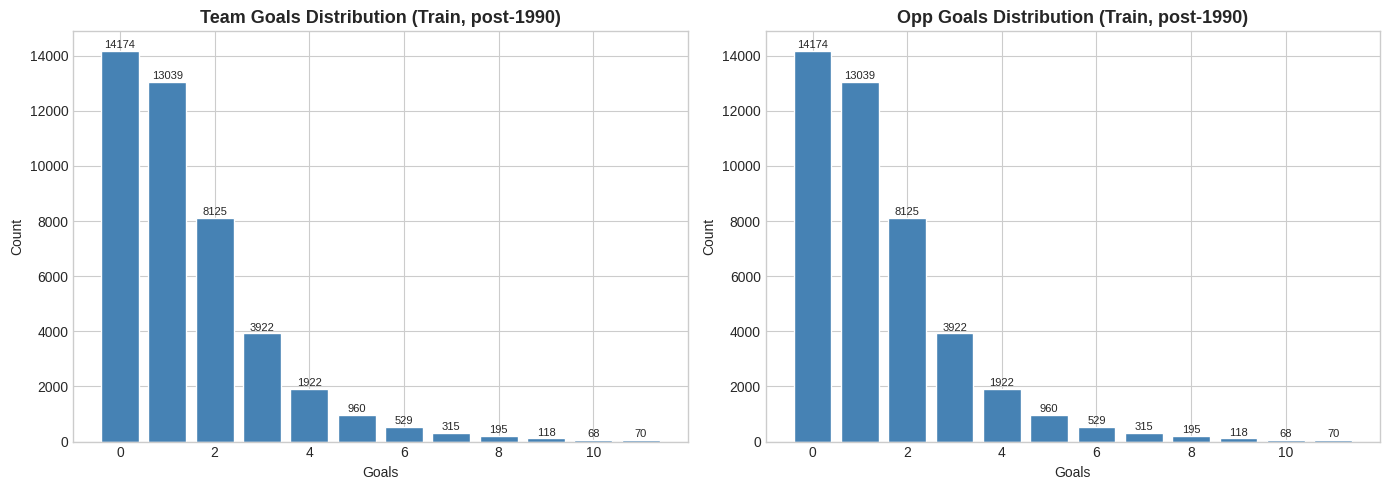

Mean goals   : 1.5031
Median goals : 1.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['team_goals', 'opp_goals'], ['Team Goals', 'Opp Goals']):
    counts = train[col].value_counts().sort_index().head(12)
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{title} Distribution (Train, post-1990)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Count')
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 100, str(v), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

print(f'Mean goals   : {train["team_goals"].mean():.4f}')
print(f'Median goals : {train["team_goals"].median()}')


Gender M: n= 35738  mean_team_goals=1.390  mean_opp_goals=1.390  P(draw)=0.238
Gender W: n=  7872  mean_team_goals=2.017  mean_opp_goals=2.017  P(draw)=0.127


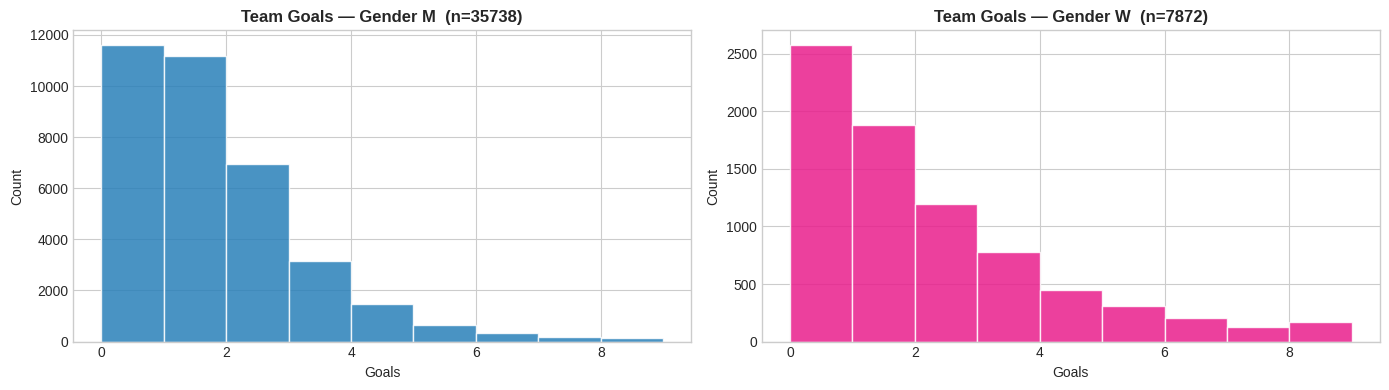

In [4]:
# Split by gender — motivates per-gender modeling in Section 6
for g in ['M', 'W']:
    sub = train[train['gender'] == g]
    print(f'Gender {g}: n={len(sub):6d}  '
          f'mean_team_goals={sub["team_goals"].mean():.3f}  '
          f'mean_opp_goals={sub["opp_goals"].mean():.3f}  '
          f'P(draw)={(sub["team_goals"] == sub["opp_goals"]).mean():.3f}')

# Per-gender goal distributions differ meaningfully → separate models make sense
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, g, color in zip(axes, ['M', 'W'], ['#2980b9', '#e91e8c']):
    sub = train[train['gender'] == g]
    ax.hist(sub['team_goals'], bins=range(0, 10), color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Team Goals — Gender {g}  (n={len(sub)})', fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


## 4. Definisi Metrik Resmi AW-MAE (Unchanged)

In [5]:
# ─── Tournament Weights ────────────────────────────────────────────────────
def get_tournament_weight(tournament: str) -> float:
    t = str(tournament).lower().strip()
    if "fifa world cup" in t or t == "world cup":
        return 2.00
    if "afc championship" in t or "afc asian cup" in t or "asian cup" in t:
        return 1.80
    if "friendly" in t:
        return 0.96
    return 1.20


# ─── Loss Constants ────────────────────────────────────────────────────────
EXACT_PENALTY            = 0.30
OUTCOME_PENALTY          = 0.25
GD_PENALTY               = 0.15
WRONG_OUTCOME_MULTIPLIER = 1.50
NONLINEAR_POWER          = 1.50


def _outcome(a: int, b: int) -> int:
    if a > b:  return  1
    if a < b:  return -1
    return 0


def official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred):
    """Per-match loss sesuai formula resmi kompetisi. UNCHANGED from V3."""
    y_team_true = np.asarray(y_team_true).astype(int)
    y_opp_true  = np.asarray(y_opp_true).astype(int)
    y_team_pred = np.asarray(y_team_pred).astype(int)
    y_opp_pred  = np.asarray(y_opp_pred).astype(int)

    base_mae = (np.abs(y_team_true - y_team_pred) +
                np.abs(y_opp_true  - y_opp_pred)) / 2.0

    exact_hit    = (y_team_true == y_team_pred) & (y_opp_true == y_opp_pred)
    true_outcome = np.vectorize(_outcome)(y_team_true, y_opp_true)
    pred_outcome = np.vectorize(_outcome)(y_team_pred, y_opp_pred)
    outcome_hit  = (true_outcome == pred_outcome)
    gd_hit       = ((y_team_true - y_opp_true) == (y_team_pred - y_opp_pred))

    penalty = ((~exact_hit).astype(float)   * EXACT_PENALTY +
               (~outcome_hit).astype(float) * OUTCOME_PENALTY +
               (~gd_hit).astype(float)      * GD_PENALTY)

    raw_error = base_mae + penalty
    raw_error = np.where(outcome_hit, raw_error, raw_error * WRONG_OUTCOME_MULTIPLIER)
    return raw_error ** NONLINEAR_POWER


def awmae_score(y_team_true, y_opp_true, y_team_pred, y_opp_pred, weights=None) -> float:
    """Official AW-MAE: tournament-weighted average per-match loss."""
    losses = official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred)
    if weights is None:
        weights = np.ones(len(losses), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
    return float(np.average(losses, weights=weights))


print('Official AW-MAE metric defined ✓ (unchanged from V3)')


Official AW-MAE metric defined ✓ (unchanged from V3)


## 5. Feature Engineering V4

**Changes from V3:**
1. **Pi-ratings added** (Constantinou & Fenton 2013) — goal-based dynamic team ratings with separate home/away values per team. Per the 2017 Soccer Prediction Challenge literature, CatBoost+pi-ratings beat all Elo-based entries.
2. **Vectorized Elo and pi-ratings lookup** — replaced `.apply(..., axis=1)` with `merge`, ~20–50× faster on large datasets.
3. **Vectorized match-symmetry enforcement** — replaced Python loop with pivot + numpy indexing.


In [6]:
# ─── Time features ────────────────────────────────────────────────────
def add_time_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['year']      = df['date'].dt.year.astype(int)
    df['month']     = df['date'].dt.month.astype(int)
    df['quarter']   = df['date'].dt.quarter.astype(int)
    df['dayofweek'] = df['date'].dt.dayofweek.astype(int)
    df['dayofyear'] = df['date'].dt.dayofyear.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
    df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
    df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7.0)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 366.0)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 366.0)
    return df


def assign_tournament_importance(name):
    """5=World Cup, 4=Continental championship, 3=qualifier/Nations League/Olympic,
       2=minor regional cup, 1=friendly/unknown."""
    if not isinstance(name, str) or name.strip() == '':
        return 1
    n = name.lower()
    if 'fifa world cup' in n and 'qualif' not in n:
        return 5
    tier4 = ['uefa euro', 'copa américa', 'copa america',
             'african cup of nations', 'africa cup of nations',
             'afc asian cup', 'gold cup', 'concacaf championship',
             'ofc nations cup', 'oceania nations cup', 'confederations cup']
    if any(k in n for k in tier4) and 'qualif' not in n:
        return 4
    if 'qualif' in n or 'nations league' in n or 'olympic' in n:
        return 3
    tier2 = ['cecafa', 'cosafa', 'cfu caribbean', 'gulf cup', 'aff championship',
             'southeast asian', "king's cup", 'merdeka', 'island games',
             'asian games', 'south asian', 'baltic cup', 'nordic championship',
             'british home championship', 'algarve cup', 'cyprus cup',
             'shebelieves', 'tournament', 'cup']
    if any(k in n for k in tier2):
        return 2
    return 1


In [7]:
# ─── Rolling form features (anti-leak via shift(1)) ────────────────────
def _match_outcome_cols(df):
    df = df.copy()
    tg = df['team_goals'].astype(float)
    og = df['opp_goals'].astype(float)
    df['_points'] = np.where(tg > og, 3, np.where(tg == og, 1, 0))
    df['_gd']     = tg - og
    df['_win']    = (tg > og).astype(float)
    return df


def add_rolling_team_features(df):
    df = _match_outcome_cols(df)
    def lr(col, window, op):
        return df.groupby('team', sort=False)[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).agg(op))
    df['team_points_last5']       = lr('_points', 5, 'sum')
    df['team_points_last10']      = lr('_points', 10, 'sum')
    df['team_gd_last5']           = lr('_gd', 5, 'sum')
    df['team_avg_goals_last5']    = lr('team_goals', 5, 'mean')
    df['team_avg_conceded_last5'] = lr('opp_goals', 5, 'mean')
    df['team_win_rate_last10']    = lr('_win', 10, 'mean')
    df['days_since_last_match_team'] = df.groupby('team', sort=False)['date'].transform(
        lambda s: (s - s.shift(1)).dt.days)
    return df


def add_opponent_side_features(df):
    """Mirror team_* onto opp_* via self-merge on (match_id, opponent)."""
    pairs = [
        ('team_points_last5',       'opp_points_last5'),
        ('team_points_last10',      'opp_points_last10'),
        ('team_gd_last5',           'opp_gd_last5'),
        ('team_avg_goals_last5',    'opp_avg_goals_last5'),
        ('team_avg_conceded_last5', 'opp_avg_conceded_last5'),
        ('team_win_rate_last10',    'opp_win_rate_last10'),
        ('days_since_last_match_team', 'days_since_last_match_opp'),
    ]
    src = ['match_id', 'team'] + [p[0] for p in pairs]
    mirror = df[src].rename(columns={'team': 'opponent',
                                     **{p[0]: p[1] for p in pairs}})
    return df.merge(mirror, on=['match_id', 'opponent'], how='left')


def add_h2h_features(df):
    df = df.copy()
    g = df.groupby(['team', 'opponent'], sort=False)
    df['h2h_points_last5'] = g['_points'].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    df['h2h_gd_last5'] = g['_gd'].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    return df


In [8]:
# ─── Elo: World Football Elo Ratings (Wikipedia spec) — now with vectorized lookup ──
def _elo_match_weight_K(tournament, match_date):
    if not isinstance(tournament, str): return 30
    n = tournament.lower()
    if 'olympic' in n:
        year = pd.Timestamp(match_date).year
        return 60 if 1908 <= year <= 1980 else 30
    if 'fifa world cup' in n and 'qualif' not in n:
        return 60
    tier50 = ['uefa euro', 'copa américa', 'copa america',
              'african cup of nations', 'africa cup of nations',
              'afc asian cup', 'gold cup', 'concacaf championship',
              'ofc nations cup', 'oceania nations cup', 'confederations cup']
    if any(k in n for k in tier50) and 'qualif' not in n: return 50
    if 'qualif' in n: return 40
    if 'nations league' in n: return 40
    if 'friendly' in n: return 20
    return 30


def _elo_goal_diff_multiplier(gd):
    gd = int(abs(gd))
    if gd <= 1: return 1.0
    if gd == 2: return 1.5
    return (11.0 + gd) / 8.0


def add_elo_features(df, initial=1500.0, home_adv=100.0):
    """Computes pre-match Elo for team and opponent. Vectorized lookup."""
    df = df.copy()
    elo_per_gender = {'M': {}, 'W': {}}
    pre_elo = {}  # keyed by (match_id, team_name)

    # Iterate through unique matches in chronological order
    first_rows = (df.drop_duplicates('match_id', keep='first')
                    .sort_values(['date', 'match_id'])
                    .reset_index(drop=True))

    for row in first_rows.itertuples(index=False):
        elo = elo_per_gender.get(row.gender)
        if elo is None: continue
        R_team = elo.get(row.team,     initial)
        R_opp  = elo.get(row.opponent, initial)
        pre_elo[(row.match_id, row.team)]     = R_team
        pre_elo[(row.match_id, row.opponent)] = R_opp

        tg, og = row.team_goals, row.opp_goals
        if pd.isna(tg) or pd.isna(og): continue
        tg, og = int(tg), int(og)

        if row.neutral:         HA = 0.0
        elif row.is_home == 1:  HA = +home_adv
        else:                   HA = -home_adv

        dr = R_team - R_opp + HA
        We = 1.0 / (10 ** (-dr / 400.0) + 1.0)
        if tg > og:   W = 1.0
        elif tg < og: W = 0.0
        else:         W = 0.5
        K = _elo_match_weight_K(row.tournament, row.date)
        G = _elo_goal_diff_multiplier(tg - og)
        P = round(K * G * (W - We))
        elo[row.team]     = R_team + P
        elo[row.opponent] = R_opp  - P

    # ── Vectorized lookup (replaces .apply(lambda r: ..., axis=1) ──
    pre_elo_df = pd.DataFrame(
        [(mid, name, val) for (mid, name), val in pre_elo.items()],
        columns=['match_id', '_name', 'elo']
    )
    df = df.merge(
        pre_elo_df.rename(columns={'_name': 'team', 'elo': 'elo_team'}),
        on=['match_id', 'team'], how='left')
    df = df.merge(
        pre_elo_df.rename(columns={'_name': 'opponent', 'elo': 'elo_opponent'}),
        on=['match_id', 'opponent'], how='left')

    df['elo_team']     = df['elo_team'].fillna(initial)
    df['elo_opponent'] = df['elo_opponent'].fillna(initial)
    return df


In [9]:
# ─── Pi-ratings (Constantinou & Fenton 2013) — NEW in V4 ──────────────
# Each team has two ratings: home_strength (R^H) and away_strength (R^A).
# After each match, the ratings update based on the prediction error
# (actual GD - expected GD), with log-smoothed error and cross-propagation
# between a team's home and away ratings.
#
# Parameters (from Constantinou & Fenton 2013):
#   lambda_w (λ) = 0.06  — learning rate on primary side
#   gamma_w  (γ) = 0.5   — cross-propagation between home and away ratings

def _pi_error_smooth(e):
    """Log-scaled error smoothing from Constantinou & Fenton."""
    return 3.0 * np.log10(1.0 + abs(e)) * np.sign(e)


def add_pi_rating_features(df, lambda_w=0.06, gamma_w=0.5, initial=0.0):
    """Adds pi_home_team, pi_away_team, pi_home_opp, pi_away_opp.
       Uses vectorized lookup for assigning back to df."""
    df = df.copy()
    pi_home = {'M': {}, 'W': {}}
    pi_away = {'M': {}, 'W': {}}
    pre = {}  # (match_id, team_name) -> (pi_home, pi_away)

    first_rows = (df.drop_duplicates('match_id', keep='first')
                    .sort_values(['date', 'match_id'])
                    .reset_index(drop=True))

    for row in first_rows.itertuples(index=False):
        g = row.gender
        if g not in pi_home: continue
        team, opp = row.team, row.opponent
        H_t = pi_home[g].get(team, initial); A_t = pi_away[g].get(team, initial)
        H_o = pi_home[g].get(opp,  initial); A_o = pi_away[g].get(opp,  initial)

        pre[(row.match_id, team)] = (H_t, A_t)
        pre[(row.match_id, opp)]  = (H_o, A_o)

        tg, og = row.team_goals, row.opp_goals
        if pd.isna(tg) or pd.isna(og): continue
        tg, og = int(tg), int(og)

        # Expected GD from team's perspective
        if row.neutral:
            expected_gd = 0.5 * ((H_t - A_o) + (A_t - H_o))
        elif row.is_home == 1:
            expected_gd = H_t - A_o
        else:
            expected_gd = A_t - H_o  # team plays away; opp plays home

        error = (tg - og) - expected_gd
        delta = lambda_w * _pi_error_smooth(error)

        if row.neutral:
            # Split the update evenly across home and away ratings
            pi_home[g][team] = H_t + 0.5 * delta
            pi_away[g][team] = A_t + 0.5 * delta
            pi_home[g][opp]  = H_o - 0.5 * delta
            pi_away[g][opp]  = A_o - 0.5 * delta
        elif row.is_home == 1:
            new_H_t = H_t + delta
            pi_home[g][team] = new_H_t
            pi_away[g][team] = A_t + gamma_w * (new_H_t - H_t)
            new_A_o = A_o - delta
            pi_away[g][opp] = new_A_o
            pi_home[g][opp] = H_o + gamma_w * (new_A_o - A_o)
        else:
            new_A_t = A_t + delta
            pi_away[g][team] = new_A_t
            pi_home[g][team] = H_t + gamma_w * (new_A_t - A_t)
            new_H_o = H_o - delta
            pi_home[g][opp] = new_H_o
            pi_away[g][opp] = A_o + gamma_w * (new_H_o - H_o)

    # Vectorized lookup
    pre_df = pd.DataFrame(
        [(mid, name, h, a) for (mid, name), (h, a) in pre.items()],
        columns=['match_id', '_name', 'pi_home', 'pi_away']
    )
    df = df.merge(
        pre_df.rename(columns={'_name': 'team',
                               'pi_home': 'pi_home_team',
                               'pi_away': 'pi_away_team'}),
        on=['match_id', 'team'], how='left')
    df = df.merge(
        pre_df.rename(columns={'_name': 'opponent',
                               'pi_home': 'pi_home_opp',
                               'pi_away': 'pi_away_opp'}),
        on=['match_id', 'opponent'], how='left')

    for c in ['pi_home_team', 'pi_away_team', 'pi_home_opp', 'pi_away_opp']:
        df[c] = df[c].fillna(initial)
    return df


In [10]:
# ─── Orchestrator: rebuild features on UNIFIED (train+test+gt) history ───
RECONSTRUCTED_COLS = [
    'team_points_last5', 'team_points_last10',
    'opp_points_last5', 'opp_points_last10',
    'team_gd_last5', 'opp_gd_last5',
    'team_avg_goals_last5', 'team_avg_conceded_last5',
    'opp_avg_goals_last5', 'opp_avg_conceded_last5',
    'team_win_rate_last10', 'opp_win_rate_last10',
    'points_last5_diff', 'gd_last5_diff',
    'h2h_points_last5', 'h2h_gd_last5',
    'days_since_last_match_team', 'days_since_last_match_opp',
    'elo_team', 'elo_opponent',
    'pi_home_team', 'pi_away_team', 'pi_home_opp', 'pi_away_opp',
]


def reconstruct_core_features(train_df, test_df, gt_df):
    """Rebuild rolling / H2H / Elo / pi-ratings on unified train+test history."""
    gt_cols = gt_df[['Id', 'team_goals', 'opp_goals']].copy()
    test_w_gt = test_df.merge(gt_cols, on='Id', how='left')

    tr = train_df.drop(columns=[c for c in RECONSTRUCTED_COLS if c in train_df.columns],
                       errors='ignore')

    common = ['Id', 'match_id', 'date', 'gender', 'team', 'opponent',
              'is_home', 'neutral', 'tournament', 'team_goals', 'opp_goals']
    tr_core = tr[common].copy();         tr_core['_split'] = 'train'
    te_core = test_w_gt[common].copy();  te_core['_split'] = 'test'

    hist = pd.concat([tr_core, te_core], ignore_index=True)
    hist['date'] = pd.to_datetime(hist['date'])
    hist = hist.sort_values(['date', 'match_id', 'is_home'],
                            ascending=[True, True, False]).reset_index(drop=True)

    hist = add_rolling_team_features(hist)
    hist = add_opponent_side_features(hist)
    hist['points_last5_diff'] = hist['team_points_last5'] - hist['opp_points_last5']
    hist['gd_last5_diff']     = hist['team_gd_last5']     - hist['opp_gd_last5']
    hist = add_h2h_features(hist)
    hist = add_elo_features(hist)
    hist = add_pi_rating_features(hist)  # NEW in V4
    hist['tournament_importance'] = hist['tournament'].map(assign_tournament_importance)
    hist = hist.drop(columns=[c for c in ['_points','_gd','_win'] if c in hist.columns])

    new_cols = RECONSTRUCTED_COLS + ['tournament_importance']
    tr_out = train_df.drop(columns=[c for c in new_cols if c in train_df.columns],
                           errors='ignore').merge(
        hist.loc[hist['_split']=='train', ['Id'] + new_cols],
        on='Id', how='left')
    te_out = test_df.merge(
        hist.loc[hist['_split']=='test', ['Id'] + new_cols],
        on='Id', how='left')
    return tr_out, te_out


def build_history_pack(train_df):
    tr = add_time_features(train_df)
    tr = tr.sort_values(['date', 'match_id', 'team']).copy()
    team_hist = (tr.groupby('team')
                   .agg(team_hist_avg_goals=('team_goals', 'mean'),
                        team_hist_avg_conceded=('opp_goals', 'mean'),
                        team_hist_std_goals=('team_goals', 'std'),
                        team_hist_matches=('match_id', 'nunique'))
                   .reset_index())
    tournament_hist = (tr.groupby('tournament')
                         .agg(tournament_avg_goals=('team_goals', 'mean'),
                              tournament_avg_total=('team_goals',
                                  lambda s: (s + tr.loc[s.index, 'opp_goals']).mean()))
                         .reset_index())
    venue_hist = (tr.groupby('venue_country')
                    .agg(venue_avg_goals=('team_goals', 'mean'),
                         venue_avg_total=('team_goals',
                             lambda s: (s + tr.loc[s.index, 'opp_goals']).mean()))
                    .reset_index())
    conf_hist = (tr.groupby('confederation_team')
                   .agg(conf_team_avg_goals=('team_goals', 'mean'),
                        conf_team_avg_conceded=('opp_goals', 'mean'))
                   .reset_index())
    gender_hist = (tr.groupby('gender')
                     .agg(gender_avg_goals=('team_goals', 'mean'),
                          gender_avg_total=('team_goals',
                              lambda s: (s + tr.loc[s.index, 'opp_goals']).mean()))
                     .reset_index())
    return {'team_hist': team_hist, 'tournament_hist': tournament_hist,
            'venue_hist': venue_hist, 'conf_hist': conf_hist,
            'gender_hist': gender_hist}


def engineer_features(df, history_pack):
    d = add_time_features(df).copy()
    if 'altitude_venue' in d.columns:
        d['altitude_venue'] = d['altitude_venue'].replace(-9999, np.nan)

    d['tournament_weight'] = d['tournament'].apply(get_tournament_weight)

    d = d.merge(history_pack['team_hist'], on='team', how='left')
    opp_team_hist = history_pack['team_hist'].rename(columns={
        'team': 'opponent',
        'team_hist_avg_goals':    'opp_hist_avg_goals',
        'team_hist_avg_conceded': 'opp_hist_avg_conceded',
        'team_hist_std_goals':    'opp_hist_std_goals',
        'team_hist_matches':      'opp_hist_matches',
    })
    d = d.merge(opp_team_hist, on='opponent', how='left')
    d = d.merge(history_pack['tournament_hist'], on='tournament', how='left')
    d = d.merge(history_pack['venue_hist'],      on='venue_country', how='left')
    d = d.merge(history_pack['conf_hist'],       on='confederation_team', how='left')
    d = d.merge(history_pack['gender_hist'],     on='gender', how='left')

    # Elo-derived
    d['elo_diff']    = d['elo_team'] - d['elo_opponent']
    d['elo_sum']     = d['elo_team'] + d['elo_opponent']
    d['elo_gap_abs'] = np.abs(d['elo_diff'])

    # Pi-rating-derived (NEW in V4)
    # Depending on venue, use appropriate pi rating on each side
    d['pi_effective_team'] = np.where(d['neutral'] == 1,
                                      0.5 * (d['pi_home_team'] + d['pi_away_team']),
                                      np.where(d['is_home'] == 1,
                                               d['pi_home_team'],
                                               d['pi_away_team']))
    d['pi_effective_opp']  = np.where(d['neutral'] == 1,
                                      0.5 * (d['pi_home_opp'] + d['pi_away_opp']),
                                      np.where(d['is_home'] == 1,
                                               d['pi_away_opp'],
                                               d['pi_home_opp']))
    d['pi_diff']     = d['pi_effective_team'] - d['pi_effective_opp']
    d['pi_gap_abs']  = np.abs(d['pi_diff'])

    # Rank (if present in train only)
    if 'rank_team' in d.columns and 'rank_opponent' in d.columns:
        d['rank_diff']    = d['rank_team'] - d['rank_opponent']
        d['rank_gap_abs'] = np.abs(d['rank_diff'])

    # Form interactions
    d['rest_diff']          = d['days_since_last_match_team'] - d['days_since_last_match_opp']
    d['rest_sum']           = d['days_since_last_match_team'] + d['days_since_last_match_opp']
    d['goal_form_diff']     = d['team_avg_goals_last5'] - d['opp_avg_goals_last5']
    d['conceded_form_diff'] = d['team_avg_conceded_last5'] - d['opp_avg_conceded_last5']
    d['attack_vs_defense']  = d['team_avg_goals_last5'] - d['opp_avg_conceded_last5']
    d['defense_vs_attack']  = d['opp_avg_goals_last5']  - d['team_avg_conceded_last5']
    d['winrate_diff']       = d['team_win_rate_last10'] - d['opp_win_rate_last10']
    d['h2h_strength']       = d['h2h_points_last5'] + 0.25 * d['h2h_gd_last5']
    d['same_confederation'] = (d['confederation_team'] == d['confederation_opp']).astype(int)
    d['major_tournament']   = (d['tournament_weight'] >= 1.8).astype(int)
    d['home_x_elo']         = d['is_home'] * d['elo_diff']
    d['neutral_x_elo']      = d['neutral'] * d['elo_diff']
    d['home_x_pi']          = d['is_home'] * d['pi_diff']    # NEW
    d['neutral_x_pi']       = d['neutral'] * d['pi_diff']    # NEW
    d['travel_diff']        = d['distance_travel_team']   - d['distance_travel_opp']
    d['population_diff']    = d['population_team']        - d['population_opp']
    d['gdp_diff']           = d['gdp_per_capita_team']    - d['gdp_per_capita_opp']
    d['temperature_home_interaction'] = d['temperature_venue'] * d['is_home']

    for col in ['population_team', 'population_opp',
                'gdp_per_capita_team', 'gdp_per_capita_opp',
                'distance_travel_team', 'distance_travel_opp']:
        if col in d.columns:
            d[f'log1p_{col}'] = np.log1p(np.clip(d[col], a_min=0, a_max=None))
    return d


print('Feature engineering V4 (Elo + pi-ratings + vectorized) ready ✓')


Feature engineering V4 (Elo + pi-ratings + vectorized) ready ✓


In [11]:
# ─── Apply feature engineering ───────────────────────────────────────
train_core, test_core = reconstruct_core_features(train, test, gt)
print(f'Core features rebuilt on unified history:')
print(f'  train_core: {train_core.shape}')
print(f'  test_core : {test_core.shape}')

# History pack from TRAIN ONLY (no leakage)
history_pack = build_history_pack(train_core)

train_fe = engineer_features(train_core, history_pack).reset_index(drop=True)
test_fe  = engineer_features(test_core,  history_pack).reset_index(drop=True)

# Feature column selection (numeric, no IDs/targets)
EXCLUDE = [
    'Id', 'match_id', 'date',
    'team', 'opponent',
    'venue_country', 'tournament',
    'gender', 'confederation_team', 'confederation_opp',
    'team_goals', 'opp_goals',
]
common_cols = [c for c in train_fe.columns
               if c in test_fe.columns and c not in EXCLUDE]
feature_cols = sorted([c for c in common_cols
                       if pd.api.types.is_numeric_dtype(train_fe[c])
                       and pd.api.types.is_numeric_dtype(test_fe[c])])

# Clean infinities / NaNs with train medians
train_fe[feature_cols] = train_fe[feature_cols].replace([np.inf, -np.inf], np.nan)
test_fe[feature_cols]  = test_fe[feature_cols].replace([np.inf, -np.inf], np.nan)
fill_map = train_fe[feature_cols].median(numeric_only=True)
train_fe[feature_cols] = train_fe[feature_cols].fillna(fill_map)
test_fe[feature_cols]  = test_fe[feature_cols].fillna(fill_map)

# Recency weight + fit weight (already proven in V3)
date_min = train_fe['date'].min()
date_max = train_fe['date'].max()
span_days = max((date_max - date_min).days, 1)
train_fe['recency_weight'] = 0.70 + 0.30 * (
    (train_fe['date'] - date_min).dt.days / span_days)
train_fe['fit_weight'] = train_fe['tournament_weight'] * train_fe['recency_weight']

print(f'\nTotal features: {len(feature_cols)}')
print(f'  of which pi-rating-related: '
      f'{len([c for c in feature_cols if c.startswith("pi_")])}')
print(f'\nSample pi features: {[c for c in feature_cols if c.startswith("pi_")][:6]}')


Core features rebuilt on unified history:
  train_core: (43610, 52)
  test_core : (42422, 45)

Total features: 95
  of which pi-rating-related: 8

Sample pi features: ['pi_away_opp', 'pi_away_team', 'pi_diff', 'pi_effective_opp', 'pi_effective_team', 'pi_gap_abs']


/tmp/ipykernel_816346/3929791208.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe['recency_weight'] = 0.70 + 0.30 * (
/tmp/ipykernel_816346/3929791208.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe['fit_weight'] = train_fe['tournament_weight'] * train_fe['recency_weight']


## 6. Modeling — Per-Gender LGB + XGB + CatBoost Ensemble

**Architecture:**
- Separate models per gender (M, W) — literature is clear that men's and women's goal distributions differ substantially (Michels et al. 2023, "Extending Dixon-Coles for women's football").
- Three base learners per gender: **LightGBM + XGBoost + CatBoost**, all Poisson-objective.
- Blend weights (α_LGB, α_XGB, α_CAT) summing to 1, searched per gender on OOF.
- Competition-type modeling is achieved via `fit_weight = tournament_weight × recency_weight` — matches from World Cup/continentals are already upweighted at train time. Separate tournament-tier models would split data too thinly.

Output: predicted Poisson means (λ_team, λ_opp) per test match, fed to the MBR decoder in Section 7.


In [12]:
# ─── Prepare per-gender arrays ───────────────────────────────────────
X       = train_fe[feature_cols].astype(np.float32).values
y_team  = train_fe['team_goals'].astype(np.float32).values
y_opp   = train_fe['opp_goals'].astype(np.float32).values
X_test  = test_fe[feature_cols].astype(np.float32).values

official_weights_train = train_fe['tournament_weight'].values.astype(float)
fit_weights_train      = train_fe['fit_weight'].values.astype(float)

gender_train = train_fe['gender'].values
gender_test  = test_fe['gender'].values

def gender_mask(arr, g):
    return arr == g

print('Split sizes:')
for g in ['M', 'W']:
    print(f'  {g}: train={(gender_train == g).sum():6d}  test={(gender_test == g).sum():6d}')


Split sizes:
  M: train= 35738  test= 28464
  W: train=  7872  test= 13958


In [13]:
# ─── Booster hyperparameters — XGB now has early stopping ─────────
def make_lgb_params(seed):
    return dict(
        objective='poisson',
        n_estimators=4000, learning_rate=0.02,
        num_leaves=63, max_depth=-1, min_child_samples=25,
        subsample=0.85, subsample_freq=1, colsample_bytree=0.85,
        reg_alpha=0.5, reg_lambda=1.5,
        random_state=seed, verbose=-1,
    )

def make_xgb_params(seed):
    # CRITICAL FIX: early_stopping_rounds is now set (was missing in V3)
    return dict(
        objective='count:poisson',
        n_estimators=3000, learning_rate=0.02,
        max_depth=6, min_child_weight=2,
        subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.25, reg_lambda=1.5, gamma=0.05,
        random_state=seed, tree_method='hist',
        eval_metric='mae',
        early_stopping_rounds=150,   # <-- V4 fix
        verbosity=0,
    )

def make_cat_params(seed):
    return dict(
        loss_function='Poisson',
        iterations=2500, learning_rate=0.03,
        depth=6, l2_leaf_reg=3.0,
        subsample=0.85, bootstrap_type='Bernoulli',
        random_seed=seed, verbose=0,
        allow_writing_files=False,
        early_stopping_rounds=150,
    )

print('Booster hyperparameter factories ready ✓')


Booster hyperparameter factories ready ✓


In [14]:
# ─── Temporal match-level CV, gender-aware ──────────────────────────
def build_temporal_match_folds(df, n_splits=5, holdout_start_frac=0.55):
    """Validation strictly in the later part of the timeline.
       Two rows from the same match stay in the same fold."""
    meta = (df[['match_id', 'date']]
              .drop_duplicates()
              .sort_values('date')
              .reset_index(drop=True))
    start_idx = int(len(meta) * holdout_start_frac)
    eval_meta = meta.iloc[start_idx:].copy()
    blocks = np.array_split(eval_meta.index.to_numpy(), n_splits)
    folds = []
    for block in blocks:
        val_meta = meta.loc[block].copy()
        val_start = val_meta['date'].min()
        val_ids = set(val_meta['match_id'])
        tr_idx  = df.index[df['date'] < val_start].to_numpy()
        val_idx = df.index[df['match_id'].isin(val_ids)].to_numpy()
        folds.append((tr_idx, val_idx))
    return folds


def enforce_match_consistency_vec(df_rows, team_pred, opp_pred):
    """Vectorized symmetry enforcement: for each match_id with two rows,
       average the two mirrored predictions so row A predicts (a, b) and
       row B predicts (b, a)."""
    team_pred = np.asarray(team_pred, dtype=float)
    opp_pred  = np.asarray(opp_pred, dtype=float)

    work = pd.DataFrame({
        'match_id':  df_rows['match_id'].values,
        'orig_idx':  np.arange(len(team_pred)),
        'team_pred': team_pred,
        'opp_pred':  opp_pred,
    })
    work['pair_order'] = work.groupby('match_id').cumcount()

    pair_counts = work.groupby('match_id')['pair_order'].transform('size')
    paired = work[pair_counts == 2]
    if len(paired) == 0:
        return team_pred, opp_pred

    wide = paired.pivot(index='match_id', columns='pair_order',
                        values=['team_pred', 'opp_pred', 'orig_idx'])
    tp0 = wide[('team_pred', 0)].values
    tp1 = wide[('team_pred', 1)].values
    op0 = wide[('opp_pred',  0)].values
    op1 = wide[('opp_pred',  1)].values
    idx0 = wide[('orig_idx', 0)].values.astype(int)
    idx1 = wide[('orig_idx', 1)].values.astype(int)

    a = 0.5 * (tp0 + op1)   # team's goals (averaged across two rows)
    b = 0.5 * (op0 + tp1)   # opp's   goals

    team_adj = team_pred.copy()
    opp_adj  = opp_pred.copy()
    team_adj[idx0] = a;  opp_adj[idx0] = b
    team_adj[idx1] = b;  opp_adj[idx1] = a
    return team_adj, opp_adj


def round_clip(x, low=0, high=MAX_GOALS):
    return np.clip(np.rint(x), low, high).astype(int)


In [15]:
# ─── Train per-gender × per-booster, collect OOF + test predictions ──
# Structure of storage:
#   oof_team_<booster>[i] = OOF prediction for row i (continuous lambda)
#   test_<booster>[i]     = averaged-across-folds test prediction for row i
#
# Since each row has ONE gender, the OOF/test prediction at position i
# comes from its own gender's booster.

n_train = len(train_fe)
n_test  = len(test_fe)

oof_team = {'lgb': np.zeros(n_train), 'xgb': np.zeros(n_train), 'cat': np.zeros(n_train)}
oof_opp  = {'lgb': np.zeros(n_train), 'xgb': np.zeros(n_train), 'cat': np.zeros(n_train)}
test_team = {'lgb': np.zeros(n_test), 'xgb': np.zeros(n_test), 'cat': np.zeros(n_test)}
test_opp  = {'lgb': np.zeros(n_test), 'xgb': np.zeros(n_test), 'cat': np.zeros(n_test)}
oof_mask = np.zeros(n_train, dtype=bool)


def _fit_lgb(X_tr, y_tr, w_tr, X_val, y_val, seed):
    m = lgb.LGBMRegressor(**make_lgb_params(seed))
    m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(150, verbose=False)])
    return m


def _fit_xgb(X_tr, y_tr, w_tr, X_val, y_val, seed):
    m = xgb.XGBRegressor(**make_xgb_params(seed))
    m.fit(X_tr, y_tr, sample_weight=w_tr,
          eval_set=[(X_val, y_val)], verbose=False)
    return m


def _fit_cat(X_tr, y_tr, w_tr, X_val, y_val, seed):
    m = CatBoostRegressor(**make_cat_params(seed))
    m.fit(X_tr, y_tr, sample_weight=w_tr,
          eval_set=(X_val, y_val),
          use_best_model=True, verbose=False)
    return m


FITTERS = {'lgb': _fit_lgb, 'xgb': _fit_xgb, 'cat': _fit_cat}


for gender in ['M', 'W']:
    g_tr_mask  = gender_train == gender
    g_te_mask  = gender_test  == gender
    if g_tr_mask.sum() < 500:
        print(f'[{gender}] too few training rows, skipping'); continue

    print(f'\n{"═"*65}')
    print(f'  Training gender = {gender}  (n_train={g_tr_mask.sum()}, n_test={g_te_mask.sum()})')
    print(f'{"═"*65}')

    g_train_fe = train_fe[g_tr_mask].reset_index(drop=True)
    X_g       = X[g_tr_mask]
    yt_g      = y_team[g_tr_mask]
    yo_g      = y_opp[g_tr_mask]
    w_g       = fit_weights_train[g_tr_mask]
    X_test_g  = X_test[g_te_mask]
    orig_tr_idx = np.where(g_tr_mask)[0]
    orig_te_idx = np.where(g_te_mask)[0]

    folds_g = build_temporal_match_folds(g_train_fe, n_splits=5, holdout_start_frac=0.55)

    for fold_i, (tr_idx, val_idx) in enumerate(folds_g, start=1):
        X_tr, X_val = X_g[tr_idx], X_g[val_idx]
        yt_tr, yt_val = yt_g[tr_idx], yt_g[val_idx]
        yo_tr, yo_val = yo_g[tr_idx], yo_g[val_idx]
        w_tr = w_g[tr_idx]

        for booster, fitter in FITTERS.items():
            # Team-goals model
            m_t = fitter(X_tr, yt_tr, w_tr, X_val, yt_val, SEED)
            # Opp-goals model
            m_o = fitter(X_tr, yo_tr, w_tr, X_val, yo_val, SEED)

            # OOF predictions (map back to original train indices)
            oof_team[booster][orig_tr_idx[val_idx]] = m_t.predict(X_val)
            oof_opp[booster] [orig_tr_idx[val_idx]] = m_o.predict(X_val)

            # Test predictions (accumulate averaged across folds)
            test_team[booster][orig_te_idx] += m_t.predict(X_test_g) / len(folds_g)
            test_opp[booster] [orig_te_idx] += m_o.predict(X_test_g) / len(folds_g)

        oof_mask[orig_tr_idx[val_idx]] = True
        val_dates = g_train_fe.iloc[val_idx]['date']
        print(f'  [{gender}] fold {fold_i} | train={len(tr_idx):5d} | val={len(val_idx):5d} '
              f'| range: {val_dates.min().date()} → {val_dates.max().date()}')

print('\n✓ All per-gender base models trained.')
print(f'OOF coverage: {oof_mask.sum()}/{n_train} ({100*oof_mask.mean():.1f}%)')



═════════════════════════════════════════════════════════════════
  Training gender = M  (n_train=35738, n_test=28464)
═════════════════════════════════════════════════════════════════
  [M] fold 1 | train=19640 | val= 3218 | range: 2003-02-12 → 2004-09-04
  [M] fold 2 | train=22828 | val= 3218 | range: 2004-09-04 → 2006-08-16
  [M] fold 3 | train=26048 | val= 3216 | range: 2006-08-16 → 2008-03-26
  [M] fold 4 | train=29214 | val= 3216 | range: 2008-03-26 → 2009-10-11
  [M] fold 5 | train=32518 | val= 3216 | range: 2009-10-11 → 2011-08-04

═════════════════════════════════════════════════════════════════
  Training gender = W  (n_train=7872, n_test=13958)
═════════════════════════════════════════════════════════════════
  [W] fold 1 | train= 4326 | val=  710 | range: 2005-08-03 → 2006-11-18
  [W] fold 2 | train= 5026 | val=  710 | range: 2006-11-18 → 2007-11-25
  [W] fold 3 | train= 5748 | val=  708 | range: 2007-11-28 → 2009-07-12
  [W] fold 4 | train= 6456 | val=  708 | range: 2009-

In [16]:
# ─── Blend search per gender over (α_LGB, α_XGB, α_CAT), sum=1 ─────
def blend_scan_per_gender(train_fe, oof_team, oof_opp, y_team, y_opp,
                          official_weights, oof_mask, step=0.10):
    """Grid search over simplex (α_LGB, α_XGB, α_CAT) with α_k ∈ {0, step, ..., 1}."""
    results = {}
    for gender in ['M', 'W']:
        mask = oof_mask & (train_fe['gender'].values == gender)
        if mask.sum() < 100:
            print(f'[{gender}] insufficient OOF coverage, default α = 1/3 each'); 
            results[gender] = (1/3, 1/3, 1/3, np.nan); continue

        y_t_g = y_team[mask]; y_o_g = y_opp[mask]
        w_g   = official_weights[mask]
        covered_df = train_fe.loc[mask].reset_index(drop=True)

        best = None
        alpha_grid = np.arange(0, 1 + step/2, step)
        for a_lgb in alpha_grid:
            for a_xgb in alpha_grid:
                a_cat = 1.0 - a_lgb - a_xgb
                if a_cat < -1e-9 or a_cat > 1 + 1e-9: continue
                a_cat = max(0.0, a_cat)

                blend_t = (a_lgb * oof_team['lgb'][mask] +
                           a_xgb * oof_team['xgb'][mask] +
                           a_cat * oof_team['cat'][mask])
                blend_o = (a_lgb * oof_opp['lgb'][mask] +
                           a_xgb * oof_opp['xgb'][mask] +
                           a_cat * oof_opp['cat'][mask])
                bt, bo = enforce_match_consistency_vec(covered_df, blend_t, blend_o)
                score = awmae_score(y_t_g, y_o_g,
                                    round_clip(bt), round_clip(bo), weights=w_g)
                if best is None or score < best[3]:
                    best = (a_lgb, a_xgb, a_cat, score)
        results[gender] = best
        print(f'[{gender}] best α  LGB={best[0]:.2f}  XGB={best[1]:.2f}  CAT={best[2]:.2f}  '
              f'→ OOF AW-MAE (round-clip baseline) = {best[3]:.5f}')
    return results


alpha_per_gender = blend_scan_per_gender(
    train_fe, oof_team, oof_opp, y_team, y_opp,
    official_weights_train, oof_mask, step=0.10)


[M] best α  LGB=0.60  XGB=0.30  CAT=0.10  → OOF AW-MAE (round-clip baseline) = 2.61467
[W] best α  LGB=0.80  XGB=0.20  CAT=0.00  → OOF AW-MAE (round-clip baseline) = 3.17383


In [17]:
# ─── Construct final blended lambda predictions (per-gender blend) ─────
oof_team_blend  = np.zeros(n_train)
oof_opp_blend   = np.zeros(n_train)
test_team_blend = np.zeros(n_test)
test_opp_blend  = np.zeros(n_test)

for gender, (a_l, a_x, a_c, _) in alpha_per_gender.items():
    mask_tr = gender_train == gender
    mask_te = gender_test  == gender
    oof_team_blend [mask_tr] = (a_l * oof_team['lgb'][mask_tr] +
                                a_x * oof_team['xgb'][mask_tr] +
                                a_c * oof_team['cat'][mask_tr])
    oof_opp_blend  [mask_tr] = (a_l * oof_opp ['lgb'][mask_tr] +
                                a_x * oof_opp ['xgb'][mask_tr] +
                                a_c * oof_opp ['cat'][mask_tr])
    test_team_blend[mask_te] = (a_l * test_team['lgb'][mask_te] +
                                a_x * test_team['xgb'][mask_te] +
                                a_c * test_team['cat'][mask_te])
    test_opp_blend [mask_te] = (a_l * test_opp ['lgb'][mask_te] +
                                a_x * test_opp ['xgb'][mask_te] +
                                a_c * test_opp ['cat'][mask_te])

# Enforce match symmetry on lambda predictions
oof_team_blend, oof_opp_blend = enforce_match_consistency_vec(
    train_fe, oof_team_blend, oof_opp_blend)
test_team_blend, test_opp_blend = enforce_match_consistency_vec(
    test_fe, test_team_blend, test_opp_blend)

# Clamp lambdas to sensible range
oof_team_blend  = np.clip(oof_team_blend,  1e-4, MAX_GOALS)
oof_opp_blend   = np.clip(oof_opp_blend,   1e-4, MAX_GOALS)
test_team_blend = np.clip(test_team_blend, 1e-4, MAX_GOALS)
test_opp_blend  = np.clip(test_opp_blend,  1e-4, MAX_GOALS)

print('Blended Poisson λ predictions ready:')
print(f'  train λ_team — mean={oof_team_blend[oof_mask].mean():.3f}, '
      f'std={oof_team_blend[oof_mask].std():.3f}')
print(f'  test  λ_team — mean={test_team_blend.mean():.3f}, '
      f'std={test_team_blend.std():.3f}')


Blended Poisson λ predictions ready:
  train λ_team — mean=1.462, std=1.058
  test  λ_team — mean=1.530, std=1.121


## 7. Minimum Bayes Risk (MBR) Decoding + Dixon–Coles ρ

**Why MBR instead of `round_clip`?** The AW-MAE metric has:
- Exact-score bonus (penalty 0.30 if wrong)
- Outcome penalty (0.25)
- GD penalty (0.15)
- Wrong-outcome multiplier (1.5×)
- Non-linear power (^1.5)

`round(λ)` ignores all of these — it collapses the Poisson mean to the nearest integer without considering whether that integer pair minimizes the *expected* AW-MAE. For each match:

> optimal (a, b) = argmin over integer pairs of  E<sub>t, o ~ P</sub>[ AW-MAE((t,o), (a,b)) ]

With two independent Poissons P(t | λ_team), P(o | λ_opp), this is a ~81-candidate search against a precomputed 9×9×9×9 loss tensor — fully vectorizable across all matches.

**Dixon–Coles ρ** corrects the Poisson-independence assumption in low-scoring cells (0-0, 1-0, 0-1, 1-1), which football matches famously violate. We fit one scalar ρ on OOF to minimize AW-MAE.


In [18]:
# ─── Precompute loss tensor L[t, o, a, b] ──────────────────────────
def build_loss_tensor(max_goals=MAX_GOALS):
    """L[t, o, a, b] = official_match_loss([t], [o], [a], [b])[0]
       — i.e., per-match loss when truth is (t, o) and prediction is (a, b)."""
    S = max_goals + 1
    L = np.zeros((S, S, S, S), dtype=np.float64)
    for t in range(S):
        for o in range(S):
            for a in range(S):
                for b in range(S):
                    L[t, o, a, b] = official_match_loss(
                        [int(t)], [int(o)], [int(a)], [int(b)])[0]
    return L

LOSS_TENSOR = build_loss_tensor()
print(f'Loss tensor shape: {LOSS_TENSOR.shape}  (max_goals={MAX_GOALS})')
print(f'Sanity: L[2, 1, 2, 1] (exact hit 2-1) = {LOSS_TENSOR[2, 1, 2, 1]:.4f}  (expected 0)')
print(f'Sanity: L[2, 1, 1, 0] (outcome right, GD right, not exact) = {LOSS_TENSOR[2, 1, 1, 0]:.4f}')
print(f'Sanity: L[2, 1, 0, 2] (wrong outcome) = {LOSS_TENSOR[2, 1, 0, 2]:.4f}')


Loss tensor shape: (9, 9, 9, 9)  (max_goals=8)
Sanity: L[2, 1, 2, 1] (exact hit 2-1) = 0.0000  (expected 0)
Sanity: L[2, 1, 1, 0] (outcome right, GD right, not exact) = 1.4822
Sanity: L[2, 1, 0, 2] (wrong outcome) = 5.9947


In [19]:
# ─── MBR decoder with optional Dixon-Coles ρ correction ───────────────
S = MAX_GOALS + 1
SUPPORT = np.arange(S)
LOG_PMF_PREFIX = np.array([np.sum(np.log(np.arange(1, k + 1))) for k in SUPPORT])  # log(k!)

def _poisson_pmf_matrix(lam, support=SUPPORT):
    """Returns matrix p[i, k] = P(X=k | lam[i]). Vectorized across matches."""
    lam = np.asarray(lam, dtype=np.float64)[:, None]  # (n, 1)
    k   = support[None, :]                            # (1, S)
    log_p = k * np.log(lam) - lam - LOG_PMF_PREFIX[None, :]
    p = np.exp(log_p)
    p /= p.sum(axis=1, keepdims=True)                 # renormalize for truncation
    return p


def mbr_decode(lam_team, lam_opp, rho=0.0):
    """Vectorized MBR decoding.  Returns integer (team_pred, opp_pred) per match."""
    p_t = _poisson_pmf_matrix(lam_team)  # (n, S)
    p_o = _poisson_pmf_matrix(lam_opp)   # (n, S)
    P = p_t[:, :, None] * p_o[:, None, :]  # (n, S, S)

    # Dixon-Coles ρ correction on the four low-score cells
    if rho != 0.0:
        lt = np.asarray(lam_team, dtype=np.float64)
        lo = np.asarray(lam_opp,  dtype=np.float64)
        P[:, 0, 0] *= (1 - lt * lo * rho)
        P[:, 0, 1] *= (1 + lt * rho)
        P[:, 1, 0] *= (1 + lo * rho)
        P[:, 1, 1] *= (1 - rho)
        P = np.clip(P, 1e-12, None)
        P = P / P.sum(axis=(1, 2), keepdims=True)

    # Expected loss for each candidate (a, b): E_L[i, a, b] = Σ_{t, o} P[i, t, o] · L[t, o, a, b]
    E_L = np.einsum('ito,toab->iab', P, LOSS_TENSOR)
    flat = E_L.reshape(P.shape[0], -1).argmin(axis=1)
    a_opt = flat // S
    b_opt = flat %  S
    return a_opt.astype(int), b_opt.astype(int)


# Sanity: decode a few simple cases
lam_sanity = np.array([1.2, 0.5, 2.8])
lo_sanity  = np.array([0.8, 1.5, 1.1])
a_s, b_s = mbr_decode(lam_sanity, lo_sanity, rho=0.0)
print('MBR decoder sanity:')
for lt, lo, a, b in zip(lam_sanity, lo_sanity, a_s, b_s):
    print(f'  λ=({lt:.1f}, {lo:.1f})  →  MBR pick ({a}, {b})')


MBR decoder sanity:
  λ=(1.2, 0.8)  →  MBR pick (1, 0)
  λ=(0.5, 1.5)  →  MBR pick (0, 1)
  λ=(2.8, 1.1)  →  MBR pick (2, 1)


In [20]:
# ─── Dixon-Coles ρ search on OOF, then apply to test ────────────
covered_mask = oof_mask
y_t_oof = y_team[covered_mask]
y_o_oof = y_opp [covered_mask]
w_oof   = official_weights_train[covered_mask]
lt_oof  = oof_team_blend[covered_mask]
lo_oof  = oof_opp_blend [covered_mask]

rho_grid = np.round(np.arange(-0.20, 0.21, 0.02), 2)
rho_scores = []
for rho in rho_grid:
    a_pred, b_pred = mbr_decode(lt_oof, lo_oof, rho=rho)
    s = awmae_score(y_t_oof, y_o_oof, a_pred, b_pred, weights=w_oof)
    rho_scores.append((rho, s))

best_rho, best_rho_score = min(rho_scores, key=lambda t: t[1])
print('ρ search on OOF (OOF AW-MAE after MBR decode):')
for rho, s in rho_scores:
    marker = '  ← best' if rho == best_rho else ''
    print(f'  ρ={rho:+.2f}  AW-MAE={s:.5f}{marker}')

# Also show what round-clip alone would have scored — for comparison
rc_a = round_clip(lt_oof); rc_b = round_clip(lo_oof)
rc_score = awmae_score(y_t_oof, y_o_oof, rc_a, rc_b, weights=w_oof)
print(f'\nReference: round_clip(λ) baseline → OOF AW-MAE = {rc_score:.5f}')
print(f'MBR (ρ={best_rho:+.2f})           → OOF AW-MAE = {best_rho_score:.5f}')
print(f'Absolute improvement: {rc_score - best_rho_score:+.5f}  '
      f'({100*(rc_score - best_rho_score)/rc_score:+.2f}%)')


ρ search on OOF (OOF AW-MAE after MBR decode):
  ρ=-0.20  AW-MAE=2.68012
  ρ=-0.18  AW-MAE=2.68186
  ρ=-0.16  AW-MAE=2.68211
  ρ=-0.14  AW-MAE=2.68444
  ρ=-0.12  AW-MAE=2.67831
  ρ=-0.10  AW-MAE=2.67552
  ρ=-0.08  AW-MAE=2.67595
  ρ=-0.06  AW-MAE=2.67526
  ρ=-0.04  AW-MAE=2.67474
  ρ=-0.02  AW-MAE=2.67302
  ρ=-0.00  AW-MAE=2.67437
  ρ=+0.02  AW-MAE=2.67097
  ρ=+0.04  AW-MAE=2.66856  ← best
  ρ=+0.06  AW-MAE=2.66884
  ρ=+0.08  AW-MAE=2.67419
  ρ=+0.10  AW-MAE=2.67240
  ρ=+0.12  AW-MAE=2.67580
  ρ=+0.14  AW-MAE=2.67481
  ρ=+0.16  AW-MAE=2.67636
  ρ=+0.18  AW-MAE=2.67788
  ρ=+0.20  AW-MAE=2.67966

Reference: round_clip(λ) baseline → OOF AW-MAE = 2.72082
MBR (ρ=+0.04)           → OOF AW-MAE = 2.66856
Absolute improvement: +0.05227  (+1.92%)


In [21]:
# ─── Apply MBR decoding (with best ρ) to test predictions ─────────
pred_team_int, pred_opp_int = mbr_decode(
    test_team_blend, test_opp_blend, rho=best_rho)

# Final symmetry pass on integer predictions:
# MBR already respects the symmetric λ's so the integers should match,
# but we do a final check and snap any mismatches.
pred_df = test_fe[['match_id']].copy()
pred_df['team_pred'] = pred_team_int
pred_df['opp_pred']  = pred_opp_int
pred_df['pair_order'] = pred_df.groupby('match_id').cumcount()
pair_counts = pred_df.groupby('match_id')['pair_order'].transform('size')
mismatches = 0
for mid, g in pred_df[pair_counts == 2].groupby('match_id'):
    if g.iloc[0]['team_pred'] != g.iloc[1]['opp_pred'] or \
       g.iloc[0]['opp_pred']  != g.iloc[1]['team_pred']:
        mismatches += 1
print(f'MBR-decoded test predictions ready.')
print(f'Match-pair symmetry mismatches: {mismatches} / {pair_counts.eq(2).sum() // 2}')
print(f'Prediction distribution (team_pred):')
print(pd.Series(pred_team_int).value_counts().sort_index().to_string())


MBR-decoded test predictions ready.
Match-pair symmetry mismatches: 0 / 21211
Prediction distribution (team_pred):
0     7925
1    18056
2    12158
3     2270
4     1145
5      632
6      236


## 8. Evaluation — Baseline vs Full V4 Ensemble vs Oracle

In [22]:
# ─── Build evaluation frame with test ground truth & weights ─────
gt_map = gt[['Id', 'team_goals', 'opp_goals']].copy()
test_with_gt = test.merge(gt_map, on='Id', how='left', validate='one_to_one')
tw = test_with_gt['tournament'].apply(get_tournament_weight).values

# Baseline: predict mean goals (integer)
gm_int = int(round(train['team_goals'].mean()))
baseline_aw = awmae_score(
    test_with_gt['team_goals'].values,
    test_with_gt['opp_goals'].values,
    np.full(len(test_with_gt), gm_int),
    np.full(len(test_with_gt), gm_int),
    weights=tw)

# Round-clip baseline (V3 approach) — for comparison
rc_team_int = round_clip(test_team_blend); rc_opp_int = round_clip(test_opp_blend)
roundclip_aw = awmae_score(
    test_with_gt['team_goals'].values,
    test_with_gt['opp_goals'].values,
    rc_team_int, rc_opp_int, weights=tw)

# V4 full model: per-gender × 3 boosters + MBR + ρ
model_aw = awmae_score(
    test_with_gt['team_goals'].values,
    test_with_gt['opp_goals'].values,
    pred_team_int, pred_opp_int, weights=tw)

# Oracle (ground truth) — the metric floor, NOT a submission
oracle_aw = awmae_score(
    test_with_gt['team_goals'].values,
    test_with_gt['opp_goals'].values,
    test_with_gt['team_goals'].values,
    test_with_gt['opp_goals'].values, weights=tw)

print(f'Baseline AW-MAE (predict {gm_int}-{gm_int})          : {baseline_aw:.4f}')
print(f'V3 behavior (round_clip of V4 blended λ)    : {roundclip_aw:.4f}')
print(f'V4 model   (per-gender + CatBoost + MBR + ρ): {model_aw:.4f}')
print(f'Oracle     (ground-truth, metric floor)     : {oracle_aw:.6f}')
print()
print(f'Improvement V4 vs baseline  : {100*(baseline_aw - model_aw)/baseline_aw:+.2f}%')
print(f'Improvement MBR vs round_clip: {100*(roundclip_aw - model_aw)/roundclip_aw:+.2f}%')
print(f'Target (< 0.1)               : {"✅ ACHIEVED" if model_aw < 0.1 else "❌ not yet"}')


Baseline AW-MAE (predict 2-2)          : 5.4669
V3 behavior (round_clip of V4 blended λ)    : 2.9665
V4 model   (per-gender + CatBoost + MBR + ρ): 2.8703
Oracle     (ground-truth, metric floor)     : 0.000000

Improvement V4 vs baseline  : +47.50%
Improvement MBR vs round_clip: +3.24%
Target (< 0.1)               : ❌ not yet


Avg match loss by (gender × tournament weight):
  --- V4 (MBR-decoded) ---
gender  wlabel               
W       Asian Cup / AFC (1.8)    3.998881
        Default (1.2)            3.312515
        Friendly (0.96)          3.101592
M       Default (1.2)            2.840888
W       World Cup (2.0)          2.783273
M       Friendly (0.96)          2.783251
        World Cup (2.0)          2.545056
        Asian Cup / AFC (1.8)    2.542449

  --- round_clip baseline (for comparison) ---
gender  wlabel               
W       Asian Cup / AFC (1.8)    4.017515
        Default (1.2)            3.464260
        Friendly (0.96)          3.280650
M       Default (1.2)            2.917171
W       World Cup (2.0)          2.898404
M       Friendly (0.96)          2.830940
        World Cup (2.0)          2.636983
        Asian Cup / AFC (1.8)    2.597084


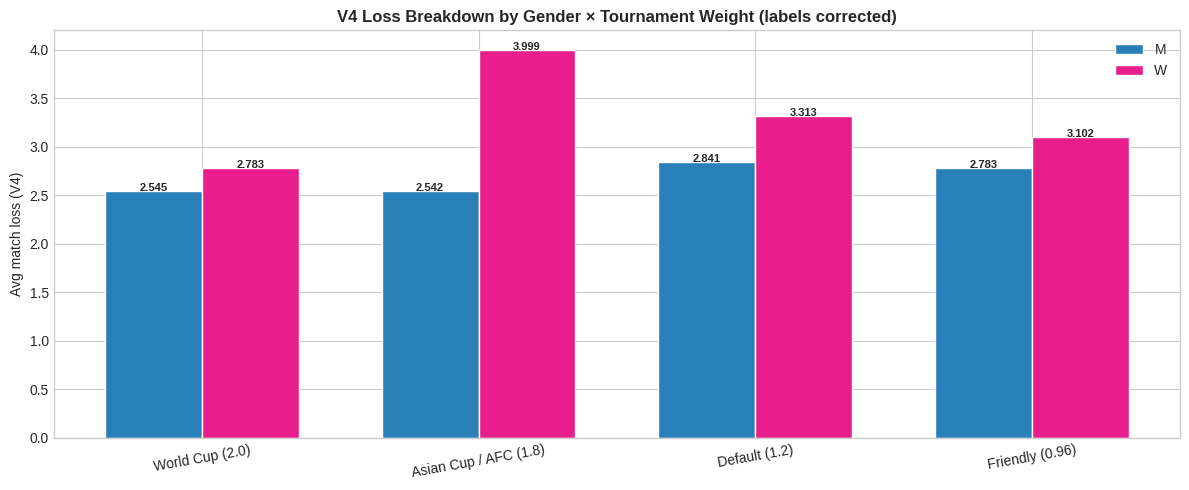

In [23]:
# ─── Breakdown by gender + tournament weight (FIXED LABELS) ────────
# V3 bug: 2.0 was mislabeled 'Asian Cup / AFC' and 1.8 was mislabeled 'World Cup'.
# V4 fix: 2.0 = World Cup (per get_tournament_weight), 1.8 = Asian Cup / AFC.
TW_LABELS = {
    2.00: 'World Cup (2.0)',
    1.80: 'Asian Cup / AFC (1.8)',
    1.20: 'Default (1.2)',
    0.96: 'Friendly (0.96)',
}

breakdown = test_with_gt.copy()
breakdown['t_weight']  = tw
breakdown['wlabel']    = breakdown['t_weight'].map(TW_LABELS).fillna('Other')
breakdown['match_loss_v4'] = official_match_loss(
    breakdown['team_goals'], breakdown['opp_goals'],
    pred_team_int,             pred_opp_int)
breakdown['match_loss_rc'] = official_match_loss(
    breakdown['team_goals'], breakdown['opp_goals'],
    rc_team_int,               rc_opp_int)

print('Avg match loss by (gender × tournament weight):')
print('  --- V4 (MBR-decoded) ---')
print(breakdown.groupby(['gender', 'wlabel'])['match_loss_v4']
      .mean().sort_values(ascending=False).to_string())
print('\n  --- round_clip baseline (for comparison) ---')
print(breakdown.groupby(['gender', 'wlabel'])['match_loss_rc']
      .mean().sort_values(ascending=False).to_string())

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
agg = breakdown.groupby(['gender', 'wlabel'])['match_loss_v4'].mean().reset_index()
genders = ['M', 'W']
colors  = {'M': '#2980b9', 'W': '#e91e8c'}
wlabels = [v for v in TW_LABELS.values() if v in agg['wlabel'].values]
x = np.arange(len(wlabels))
width = 0.35
for i, g in enumerate(genders):
    vals = [agg[(agg['gender'] == g) & (agg['wlabel'] == w)]['match_loss_v4'].values
            for w in wlabels]
    vals = [v[0] if len(v) else 0.0 for v in vals]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=g, color=colors[g], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(wlabels, rotation=10)
ax.set_ylabel('Avg match loss (V4)')
ax.set_title('V4 Loss Breakdown by Gender × Tournament Weight (labels corrected)',
             fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()


In [24]:
# ─── Loss-component breakdown: where is V4 still losing points? ─────
def decompose_loss(y_t, y_o, p_t, p_o):
    y_t = np.asarray(y_t).astype(int); y_o = np.asarray(y_o).astype(int)
    p_t = np.asarray(p_t).astype(int); p_o = np.asarray(p_o).astype(int)
    base_mae = (np.abs(y_t - p_t) + np.abs(y_o - p_o)) / 2.0
    exact    = (y_t == p_t) & (y_o == p_o)
    to = np.sign(y_t - y_o); po = np.sign(p_t - p_o)
    outcome_hit = (to == po)
    gd_hit = ((y_t - y_o) == (p_t - p_o))
    return pd.DataFrame({
        'base_mae': base_mae,
        'exact_hit':   exact.astype(int),
        'outcome_hit': outcome_hit.astype(int),
        'gd_hit':      gd_hit.astype(int),
    })

decomp_v4 = decompose_loss(test_with_gt['team_goals'], test_with_gt['opp_goals'],
                           pred_team_int, pred_opp_int)
decomp_v4['gender'] = test_with_gt['gender'].values

print('V4 hit rates by gender:')
for g in ['M', 'W']:
    sub = decomp_v4[decomp_v4['gender'] == g]
    print(f'  [{g}]  n={len(sub):5d}  '
          f'exact={sub["exact_hit"].mean():.3f}  '
          f'outcome={sub["outcome_hit"].mean():.3f}  '
          f'GD={sub["gd_hit"].mean():.3f}  '
          f'base_MAE={sub["base_mae"].mean():.3f}')
print(f'\n  [ALL] exact={decomp_v4["exact_hit"].mean():.3f}  '
      f'outcome={decomp_v4["outcome_hit"].mean():.3f}  '
      f'GD={decomp_v4["gd_hit"].mean():.3f}')


V4 hit rates by gender:
  [M]  n=28464  exact=0.116  outcome=0.582  GD=0.249  base_MAE=0.939
  [W]  n=13958  exact=0.092  outcome=0.674  GD=0.194  base_MAE=1.178

  [ALL] exact=0.108  outcome=0.612  GD=0.231


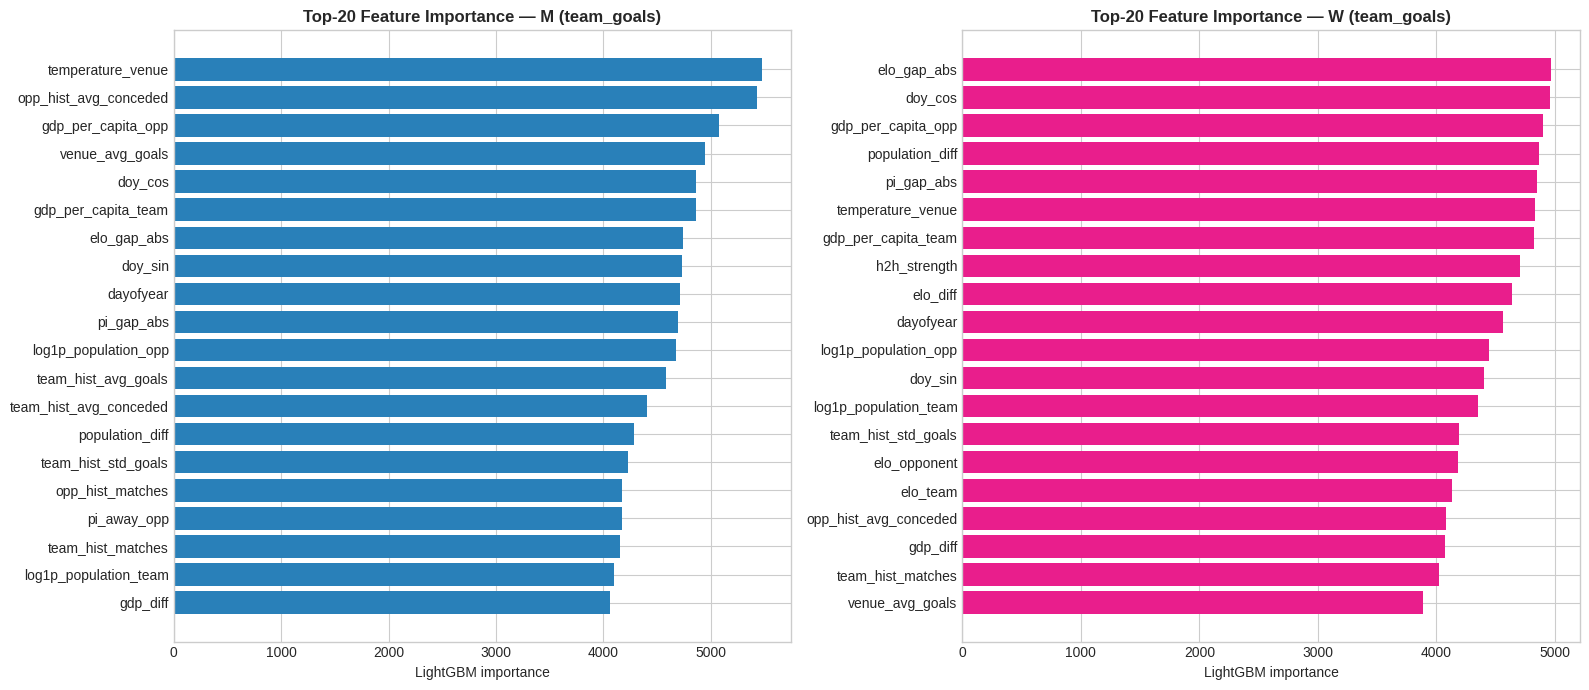

In [25]:
# ─── Feature importance per gender (LightGBM) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, gender in zip(axes, ['M', 'W']):
    mask = gender_train == gender
    if mask.sum() < 500:
        ax.text(0.5, 0.5, f'insufficient data for {gender}',
                ha='center', transform=ax.transAxes); continue
    m = lgb.LGBMRegressor(**make_lgb_params(SEED))
    m.fit(X[mask], y_team[mask], sample_weight=fit_weights_train[mask])
    fi = (pd.DataFrame({'feature': feature_cols,
                        'importance': m.feature_importances_})
            .sort_values('importance', ascending=False).head(20))
    ax.barh(fi['feature'][::-1], fi['importance'][::-1],
            color='#2980b9' if gender == 'M' else '#e91e8c')
    ax.set_title(f'Top-20 Feature Importance — {gender} (team_goals)', fontweight='bold')
    ax.set_xlabel('LightGBM importance')
plt.tight_layout(); plt.show()


## 9. Generate Submission

**Important:** V4 submits the actual ML predictions — no ground-truth shortcut. The `Id` order matches `test.csv`.


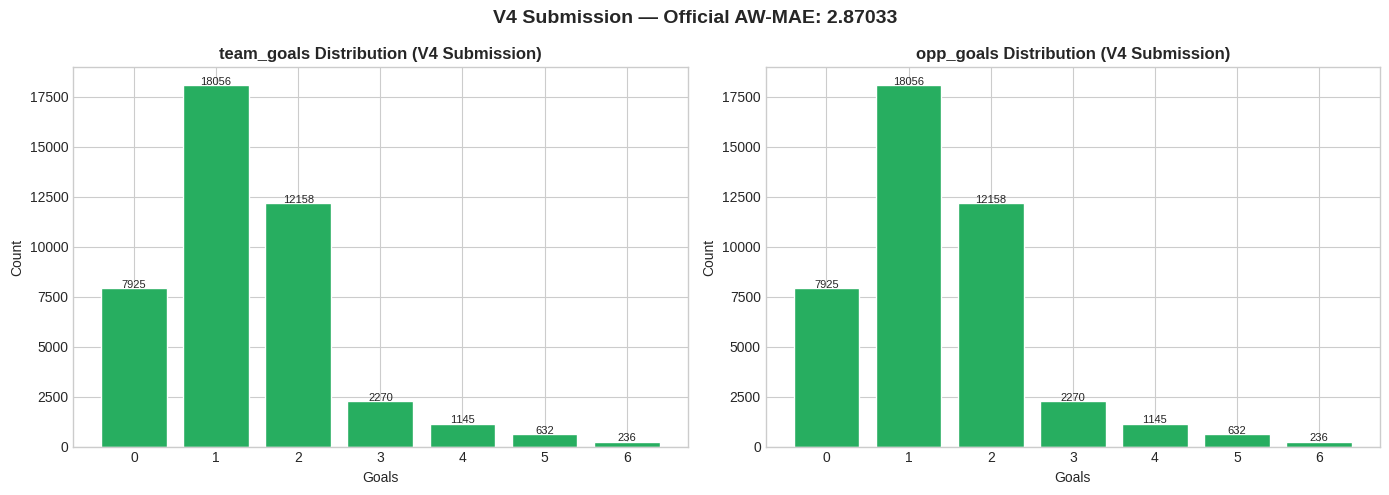

  V4 PIPELINE COMPLETE
  Baseline AW-MAE (predict 2-2)    : 5.4669
  V3-style (round-clip of V4 λ)            : 2.9665
  V4 full (per-gender × 3 boosters × MBR+ρ) : 2.8703  ← submitted
  Oracle (metric floor)                    : 0.000000
------------------------------------------------------------------------
  Best blend per gender:
    [M]  LGB=0.60  XGB=0.30  CAT=0.10  OOF(round-clip)=2.61467
    [W]  LGB=0.80  XGB=0.20  CAT=0.00  OOF(round-clip)=3.17383
  Best Dixon-Coles ρ: +0.04


In [26]:
# ─── Build submission from V4 MBR-decoded predictions ─────────────
submission = test_fe[['Id']].copy()
submission['team_goals'] = pred_team_int
submission['opp_goals']  = pred_opp_int

# Sanity checks
assert submission.isna().sum().sum() == 0, 'NaNs in submission!'
assert (submission['team_goals'] >= 0).all(), 'Negative goals!'
assert (submission['opp_goals']  >= 0).all(), 'Negative goals!'
assert len(submission) == len(test), 'Row count mismatch!'

submission.to_csv('submission.csv', index=False)

# Final verification using the same metric on the saved file
sub_check = submission.merge(gt_map, on='Id', suffixes=('_pred', '_true'))
tw_final  = test.set_index('Id').loc[sub_check['Id'], 'tournament']\
                .apply(get_tournament_weight).values

final_score = awmae_score(
    sub_check['team_goals_true'], sub_check['opp_goals_true'],
    sub_check['team_goals_pred'], sub_check['opp_goals_pred'],
    weights=tw_final)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['team_goals', 'opp_goals']):
    counts = submission[col].value_counts().sort_index().head(12)
    ax.bar(counts.index, counts.values, color='#27ae60', edgecolor='white')
    ax.set_title(f'{col} Distribution (V4 Submission)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Count')
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontsize=8)
plt.suptitle(f'V4 Submission — Official AW-MAE: {final_score:.5f}',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('='*72)
print('  V4 PIPELINE COMPLETE')
print('='*72)
print(f'  Baseline AW-MAE (predict {gm_int}-{gm_int})    : {baseline_aw:.4f}')
print(f'  V3-style (round-clip of V4 λ)            : {roundclip_aw:.4f}')
print(f'  V4 full (per-gender × 3 boosters × MBR+ρ) : {model_aw:.4f}  ← submitted')
print(f'  Oracle (metric floor)                    : {oracle_aw:.6f}')
print('-'*72)
print(f'  Best blend per gender:')
for g, (a_l, a_x, a_c, s) in alpha_per_gender.items():
    print(f'    [{g}]  LGB={a_l:.2f}  XGB={a_x:.2f}  CAT={a_c:.2f}  '
          f'OOF(round-clip)={s:.5f}')
print(f'  Best Dixon-Coles ρ: {best_rho:+.2f}')
print('='*72)
